(ch:inference)=
# 4. Bayesian inference

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* recognize and carry out the three steps of Bayesian inference: choose a prior, write down the statistical (generative) model and its likelihood, compute the posterior;
* compute a posterior on a grid, normalize it, marginalize over nuisance parameters and read off credible intervals;
* include *intrinsic scatter* as an extra parameter of the statistical model, and explain how it relates to $\chi^2$ rescaling and to the $p$-value of a null hypothesis;
* explain the difference between a frequentist confidence interval and a Bayesian credible interval, and summarize a posterior distribution in a report.

This chapter accompanies the second part of Lecture 3, the first part of Lecture 4 and Lecture 6. We return to Blinky, the star of Chapter {ref}`1 <ch:testing>`.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize, integrate

rng = np.random.default_rng(8)          # same seed as Chapter 1: we get the same dataset
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## 4.1 The three steps of Bayesian inference

*Inference* means drawing conclusions about unknown quantities (parameters, hypotheses) from evidence (data). Bayesian inference does this with Bayes' theorem, Eq. {eq}`eq:bayes-parameters` of Chapter 3, and always consists of the same three steps.

```{admonition} The three steps
:class: important
1. **Choose a prior**, $p(\theta)$: what do we know about the parameters before seeing the data? Often a flat (constant) prior over a reasonable range, sometimes something more informative (Chapter {ref}`5 <ch:priors>`).
2. **Choose a statistical model.** We need a *generative* model, $y \sim p(y\,|\,\theta, x)$, a recipe to simulate data given the parameters. This defines the **likelihood** $p(y\,|\,\theta)$ (Chapter 1).
3. **Compute the posterior** with Bayes' theorem,
   $$
   p(\theta\,|\,y) \propto p(\theta)\,p(y\,|\,\theta) ,
   $$
   either on a grid of parameter values (this chapter) or by drawing samples from it with MCMC (Chapter {ref}`6 <ch:mcmc>`).
```

The output of step 3 is a *probability distribution* over the parameters, not a single number. Everything we may want to report (a best value, an uncertainty, the probability that a parameter exceeds some threshold) is derived from that distribution afterwards.

**Notation with $x$ and $\sigma_y$.** For data of the form $(x_i, y_i, \sigma_{y,i})$ with a model $m(x,\theta)$ the three steps read: prior $p(\theta)$ (it may depend on $x$ but usually does not); generative model $y_i \sim \mathcal{N}(m(x_i,\theta), \sigma_{y,i}^2)$ giving the likelihood $p(y\,|\,\theta, x, \sigma_y)$; posterior $p(\theta\,|\,y, x, \sigma_y) \propto p(\theta)\,p(y\,|\,\theta, x, \sigma_y)$. The $x_i$ and $\sigma_{y,i}$ are "experimental design", always conditioned upon, and we mostly leave them out of the notation.

## 4.2 A one-parameter example: the rate of a Poisson process

A detector counts particles. The probability of $y$ counts when the expectation value is $\lambda$ is the Poisson distribution, $p(y\,|\,\lambda) = \lambda^y e^{-\lambda}/y!$. We observe $y=2$ counts in $t=10$ s and want to infer the *rate* $\theta$ (counts per second), so $\lambda = \theta t = 10\theta$.

1. *Prior:* flat, $p(\theta) = $ const for $\theta \geq 0$.
2. *Model:* $y \sim \mathrm{Poisson}(10\theta)$, so the likelihood is $p(y=2\,|\,\theta) = (10\theta)^2 e^{-10\theta}/2! = 50\,\theta^2 e^{-10\theta}$.
3. *Posterior:* $p(\theta\,|\,y=2) = p(y=2\,|\,\theta)\,p(\theta)/p(y=2)$. The evidence is $p(y=2) = \int_0^\infty 50\,\theta^2 e^{-10\theta}\,d\theta = 50\cdot 2/10^3 = 0.1$, so

$$
p(\theta\,|\,y=2) = 500\,\theta^2 e^{-10\theta} .
$$

This is a Gamma distribution; it peaks at $\theta = 0.2$ s$^{-1}$ (the maximum-likelihood value $x/t$), it is zero at $\theta = 0$ and has a tail towards high rates. Let's confirm numerically, on a grid.

evidence p(y=2) from the grid: 0.0999   (analytic: 0.1)


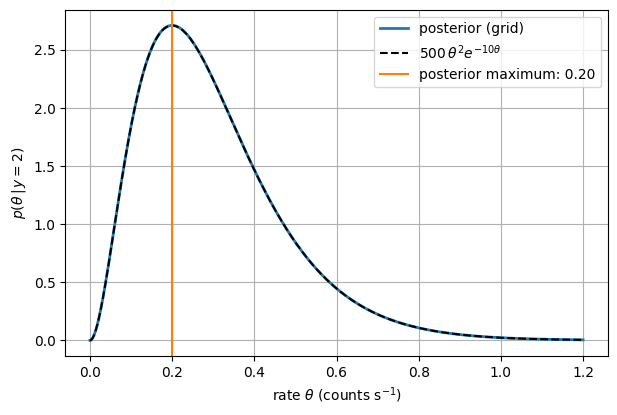

In [2]:
theta = np.linspace(0, 1.2, 1201)
y_obs, t_obs = 2, 10.0

prior = np.ones_like(theta)                                   # step 1
like = stats.poisson.pmf(y_obs, theta * t_obs)                # step 2
post_unnorm = prior * like                                    # step 3 ...
post = post_unnorm / np.trapezoid(post_unnorm, theta)         # ... normalized on the grid

print(f"evidence p(y=2) from the grid: {np.trapezoid(like * prior, theta):.4f}   (analytic: 0.1)")

fig, ax = plt.subplots()
ax.plot(theta, post, lw=2, label="posterior (grid)")
ax.plot(theta, 500 * theta**2 * np.exp(-10 * theta), "k--", label=r"$500\,\theta^2 e^{-10\theta}$")
ax.axvline(theta[np.argmax(post)], color="C1", label=f"posterior maximum: {theta[np.argmax(post)]:.2f}")
ax.set_xlabel(r"rate $\theta$ (counts s$^{-1}$)"); ax.set_ylabel(r"$p(\theta\,|\,y=2)$"); ax.legend();

### Credible intervals

A **credible interval** at level $\gamma$ is any interval $(\theta_{\rm l}, \theta_{\rm u})$ that contains a fraction $\gamma$ of the posterior probability:

$$
\int_{\theta_{\rm l}}^{\theta_{\rm u}} p(\theta\,|\,y)\,d\theta = \gamma .
$$ (eq:credible)

This condition does not fix the interval uniquely, and two conventions are in use:

* the **equal-tailed** interval, which leaves $(1-\gamma)/2$ of the probability on either side, i.e. runs from the $(1-\gamma)/2$ to the $(1+\gamma)/2$ quantile of the posterior (for $\gamma = 0.683$: the 15.9% and 84.1% percentiles);
* the **highest-density** (or shortest) interval, which contains the most probable values; for a skewed posterior it is shifted towards the peak, and for a multimodal posterior it may consist of several pieces.

For a symmetric posterior both coincide. The equal-tailed interval is fast and easy to explain, so we usually use that one. On a grid, both are computed from the cumulative distribution:

In [3]:
def equal_tailed_interval(grid, post, gamma=0.683):
    """equal-tailed credible interval from a posterior evaluated on a grid"""
    cdf = integrate.cumulative_trapezoid(post, grid, initial=0)
    cdf /= cdf[-1]
    return np.interp([(1 - gamma) / 2, (1 + gamma) / 2], cdf, grid)

def highest_density_interval(grid, post, gamma=0.683):
    """shortest interval containing a fraction gamma of the posterior (assumes a unimodal posterior)"""
    cdf = integrate.cumulative_trapezoid(post, grid, initial=0)
    cdf /= cdf[-1]
    lower = np.interp(np.linspace(0, 1 - gamma, 500), cdf, grid)       # candidate lower bounds
    upper = np.interp(np.linspace(gamma, 1, 500), cdf, grid)           # matching upper bounds
    i = np.argmin(upper - lower)
    return lower[i], upper[i]

for gamma in [0.683, 0.90]:
    lo, hi = equal_tailed_interval(theta, post, gamma)
    lo2, hi2 = highest_density_interval(theta, post, gamma)
    print(f"{gamma*100:.1f}% credible interval:  equal-tailed ({lo:.3f}, {hi:.3f});  highest-density ({lo2:.3f}, {hi2:.3f})")

68.3% credible interval:  equal-tailed (0.137, 0.464);  highest-density (0.086, 0.385)
90.0% credible interval:  equal-tailed (0.082, 0.628);  highest-density (0.044, 0.547)


With only two counts the rate is poorly constrained: the 90% interval spans almost a factor of eight. Note that the answer is a statement about $\theta$: "with 90% probability the rate lies between 0.08 and 0.63 counts per second". A frequentist is not allowed to say this (Section {ref}`4.6 <sec:reporting>`).

### Many counts: Blinky again

Now take the 100 exposures of Chapter 1 (same seed, same data) and infer the mean count rate $\mu$ with a Poisson likelihood and a flat prior. The likelihood is a product of 100 Poisson terms, so we work with logarithms and subtract the maximum before exponentiating, to avoid underflow.

mu = 1001.3 -3.1 +3.2  (68.3% credible interval)
compare: sample mean 1001.3, standard error of the mean sqrt(mean/N) = 3.2


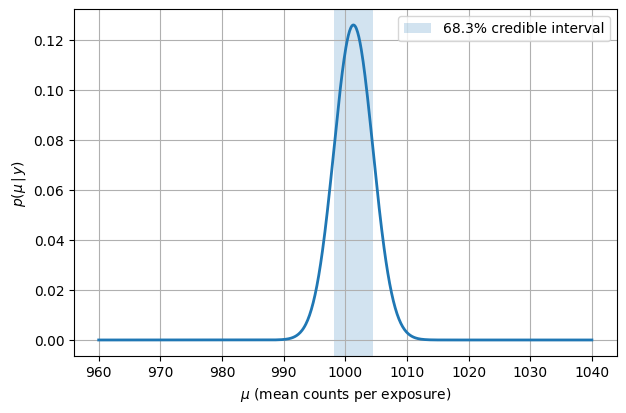

In [4]:
N = 100
mu_true, eps_true = 1000, 15
F_true = rng.normal(mu_true, eps_true, size=N)
y = rng.poisson(F_true)
sigma_y = np.sqrt(y)

mu_grid = np.linspace(960, 1040, 801)
log_like = np.array([np.sum(stats.poisson.logpmf(y, mu)) for mu in mu_grid])   # step 2
log_post = log_like + 0.0                                                      # step 1: flat prior adds a constant
post_mu = np.exp(log_post - log_post.max())                                    # step 3
post_mu /= np.trapezoid(post_mu, mu_grid)

lo, hi = equal_tailed_interval(mu_grid, post_mu)
mu_map = mu_grid[np.argmax(post_mu)]
print(f"mu = {mu_map:.1f} -{mu_map-lo:.1f} +{hi-mu_map:.1f}  (68.3% credible interval)")
print(f"compare: sample mean {np.mean(y):.1f}, standard error of the mean sqrt(mean/N) = {np.sqrt(np.mean(y)/N):.1f}")

fig, ax = plt.subplots()
ax.plot(mu_grid, post_mu, lw=2)
ax.axvspan(lo, hi, alpha=0.2, label="68.3% credible interval")
ax.set_xlabel(r"$\mu$ (mean counts per exposure)"); ax.set_ylabel(r"$p(\mu\,|\,y)$"); ax.legend();

With 100 data points the posterior is nearly Gaussian and the credible interval coincides with the frequentist standard error of the mean. This is the general rule: **with lots of data and a flat prior, Bayesian and frequentist answers agree.** The differences appear with little data, with informative priors, and, most importantly, with nuisance parameters. But there is something wrong with this analysis: it assumes the source is constant, and in Chapter 1 we found $2\sigma$ evidence that it is not. The next section fixes this.

## 4.3 Grid search: the general recipe

The two examples above are grid searches: evaluate the unnormalized posterior on a grid of parameter values, normalize, done. For $k$ parameters with $M$ grid points each this costs $M^k$ likelihood evaluations, which is fine for one or two parameters and hopeless for ten (Chapter {ref}`6 <ch:mcmc>` is the solution). A few practical rules:

* Work with **log-probabilities** and subtract the maximum before exponentiating.
* Start with a **coarse grid** over the whole prior range to locate the posterior, then refine around it. Make sure the grid extends far enough into the tails that the posterior is negligible at the edges (otherwise the normalization and the intervals are wrong).
* **Marginalize** by summing the normalized grid over the other axes (the integral of Eq. {eq}`eq:marginalization` becomes a sum):
  $p(\theta_1\,|\,y) \approx \sum_j p(\theta_1, \theta_{2,j}\,|\,y)\,\Delta\theta_2$.
* Read off credible intervals from the marginal posteriors, and draw contours of the joint posterior that enclose 68% and 95% of the probability.

## 4.4 Intrinsic scatter as part of the statistical model

### The likelihood with an extra variance

Up to now, the Gaussian generative model always used the measurement uncertainty as the width of the distribution: $y_i \sim \mathcal{N}(\mu_i, \sigma_{y,i}^2)$ with $\mu_i = m(x_i, \theta)$. What if the data scatter more than that, because the source is intrinsically variable, because the relation we fit has intrinsic width, or simply because the reported uncertainties are too small? We add an extra variance $\epsilon^2$ to the model:

$$
y_i \sim \mathcal{N}\!\left(m(x_i,\theta),\; \sigma_{y,i}^2 + \epsilon^2\right) .
$$ (eq:generative-eps)

```{admonition} Derivation (from the board in Lecture 4)
:class: note
A single Gaussian data point with mean $\mu_i$ and variance $s_i^2$ has probability density $p(y_i) = (2\pi s_i^2)^{-1/2}\exp[-(y_i-\mu_i)^2/2s_i^2]$. Its logarithm is

$$
\ln p(y_i) = -\tfrac12\ln(2\pi) - \tfrac12\ln s_i^2 - \frac{(y_i-\mu_i)^2}{2 s_i^2} .
$$

As long as $s_i$ is a *known* number, the first two terms are constants and only the last one matters: that is the least-squares case of Chapter 1. Now put $s_i^2 = \sigma_{y,i}^2 + \epsilon^2$ with $\epsilon$ a free parameter. The term $-\tfrac12\ln s_i^2$ now depends on $\epsilon$ and must be kept:

$$
\ln p(y_i\,|\,\mu_i, \epsilon) \propto -\frac12\left[\ln\left(\sigma_{y,i}^2+\epsilon^2\right) + \frac{(y_i-\mu_i)^2}{\sigma_{y,i}^2+\epsilon^2}\right] ,
$$

where $\propto$ means "up to an additive constant". Summing over independent data points gives Eq. {eq}`eq:loglike-eps` below. The posterior of the constant-mean model becomes $p(\mu, \epsilon\,|\,y, \sigma_y)$: two parameters instead of one.
```

The log-likelihood of one data point is then

$$
\ln p(y_i\,|\,\theta, \epsilon) = -\frac{1}{2}\ln\!\left[2\pi\left(\sigma_{y,i}^2 + \epsilon^2\right)\right] - \frac{[y_i - m(x_i,\theta)]^2}{2\left(\sigma_{y,i}^2 + \epsilon^2\right)} ,
$$

and for the whole dataset, writing $s_i^2 \equiv \sigma_{y,i}^2 + \epsilon^2$,

$$
\ln \mathcal{L}(\theta, \epsilon) = -\frac{1}{2}\sum_{i=1}^{N}\left[\ln\left(2\pi s_i^2\right) + \frac{[y_i - m(x_i,\theta)]^2}{s_i^2}\right] .
$$ (eq:loglike-eps)

Compare with Eq. {eq}`eq:loglike-chi2`: the $\ln s_i^2$ term is no longer a constant, because it contains the parameter $\epsilon$. **This is no longer least squares.** The second term alone would always prefer $\epsilon\to\infty$ (residuals divided by an enormous variance are tiny); the first term penalizes a large variance. Their balance determines $\epsilon$: finally something that $\chi^2$-minimization cannot do.

```{admonition} Can I use this likelihood in curve_fit?
:class: warning
No. `curve_fit` minimizes $\sum_i [y_i - m(x_i,\theta)]^2/\sigma_i^2$ with the $\sigma_i$ *fixed*; it has no way to include a parameter-dependent normalization term. You need a general optimizer (`scipy.optimize.minimize` on $-\ln\mathcal{L}$), a grid, or MCMC.
```

**Connection to $\chi^2$ rescaling.** Maximizing Eq. {eq}`eq:loglike-eps` over $\epsilon$ produces an "effective" variance for which $\chi^2/\mathrm{dof} \approx 1$, i.e. it does roughly what `absolute_sigma=False` does. So why bother? Because the data now *tell us* how much extra scatter there is, with a posterior distribution for $\epsilon$; because we can *marginalize* over $\epsilon$ and obtain realistic uncertainties on $\theta$ that include our ignorance about the scatter; and because in many problems $\epsilon$ is itself the physically interesting quantity (the intrinsic width of a relation, the variability amplitude of a source).

**Connection to hypothesis testing.** The null hypothesis of Chapter 1, "the source is not variable", is $\epsilon = 0$. If the posterior of $\epsilon$ excludes zero, we have evidence for variability; the credible interval replaces the $p$-value, and it also tells us *how* variable the source is.

```{admonition} A multiplicative variant
:class: note
Sometimes the extra scatter is better described as a fraction $f$ of the model value, $s_i^2 = \sigma_{y,i}^2 + f^2 m(x_i,\theta)^2$; the `emcee` documentation uses this form, with $\ln f$ as the free parameter. Everything in this section applies unchanged.
```

### Maximum likelihood, AIC and BIC

For the Blinky data the model is a constant, $m(x_i,\theta) = \mu$, so the statistical model has two parameters, $(\mu, \epsilon)$, and the log-likelihood is Eq. {eq}`eq:loglike-eps` with $\sigma_{y,i} = \sqrt{y_i}$. We first maximize it numerically and check with the information criteria whether the extra parameter is warranted.

In [5]:
def log_like_eps(theta, y, sigma_y):
    """Gaussian log-likelihood for a constant mean mu with extra variance eps^2 (Eq. loglike-eps)"""
    mu, eps = theta
    s2 = sigma_y**2 + eps**2
    return -0.5 * np.sum(np.log(2 * np.pi * s2) + (y - mu)**2 / s2)

neg_log_like = lambda theta: -log_like_eps(theta, y, sigma_y)
res = optimize.minimize(neg_log_like, x0=[900, 5], method="Nelder-Mead")
mu_hat, eps_hat = res.x
print(f"maximum likelihood: mu = {mu_hat:.1f}, eps = {eps_hat:.1f}")

w = 1 / sigma_y**2
mu_wmean = np.sum(w * y) / np.sum(w)                           # the best fit without intrinsic scatter
ll_0 = log_like_eps([mu_wmean, 0.0], y, sigma_y)
ll_1 = log_like_eps([mu_hat, eps_hat], y, sigma_y)
print(f"AIC: {-2*ll_0 + 2*1:.1f} (eps=0)  ->  {-2*ll_1 + 2*2:.1f} (eps free);  change {-2*ll_1 + 4 - (-2*ll_0 + 2):+.1f}")
print(f"BIC: {-2*ll_0 + np.log(N)*1:.1f} (eps=0)  ->  {-2*ll_1 + np.log(N)*2:.1f} (eps free);  change {-2*ll_1 + 2*np.log(N) - (-2*ll_0 + np.log(N)):+.1f}")
delta = -2 * ll_0 - (-2 * ll_1)
print(f"drop in -2 ln L: {delta:.1f}  ->  likelihood-ratio test p-value {stats.chi2.sf(delta, 1):.3f}")

maximum likelihood: mu = 1000.3, eps = 18.1
AIC: 1008.5 (eps=0)  ->  1006.0 (eps free);  change -2.5
BIC: 1011.1 (eps=0)  ->  1011.2 (eps free);  change +0.1
drop in -2 ln L: 4.5  ->  likelihood-ratio test p-value 0.034


The AIC decreases when $\epsilon$ is added; the BIC, with its stronger penalty, is indifferent. This matches the modest evidence for variability from the hypothesis test in Chapter 1 ($p\approx 0.015$): real, but not strong. The connection is not a coincidence. For one extra parameter, a drop $\Delta$ in $-2\ln\mathcal{L}$ corresponds (asymptotically, for nested models) to a $p$-value of $P(\chi^2_1 > \Delta)$; this is the *likelihood-ratio test*, and the AIC rewards the extra parameter as soon as $\Delta > 2$, i.e. $p \lesssim 0.16$.

### The posterior on a grid

Now the Bayesian version. Priors: flat in $\mu$ and flat in $\epsilon$ with the physical constraint $\epsilon \geq 0$ (a negative standard deviation is meaningless; more about such priors in Chapter 5). We evaluate the posterior on a two-dimensional grid, marginalize, and report credible intervals.

mu : median  1000.3, 68.3% interval (996.7, 1004.0), 95.4% interval (993.0, 1007.7)
eps: median    17.7, 68.3% interval (11.4, 23.0), 95.4% interval (3.3, 28.1)


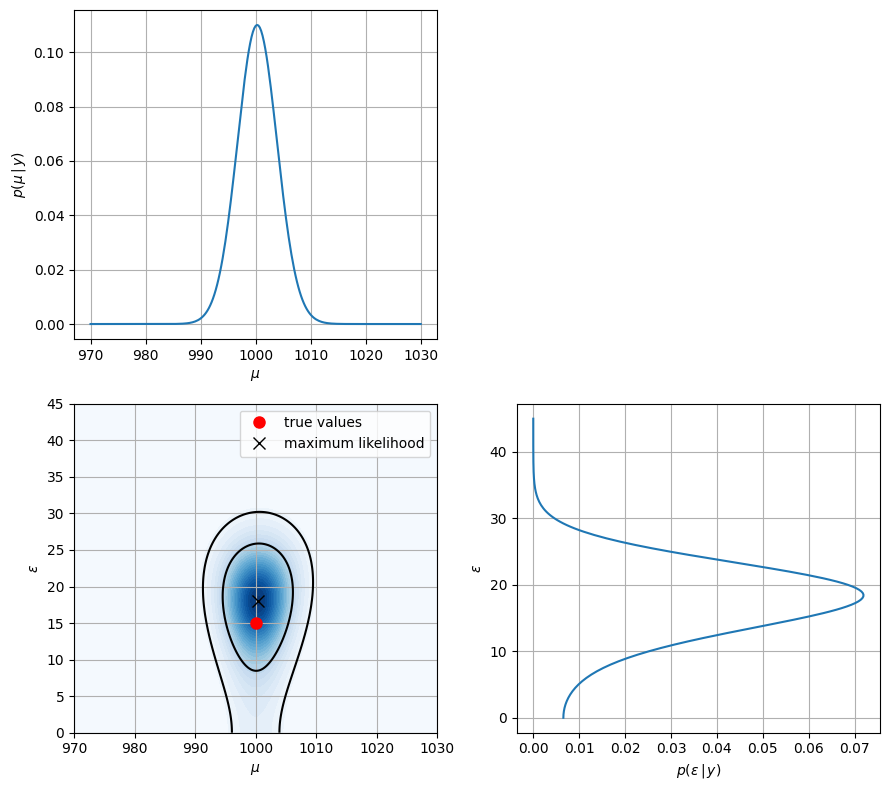

In [6]:
mu_grid = np.linspace(970, 1030, 241)
eps_grid = np.linspace(0, 45, 181)
MU, EPS = np.meshgrid(mu_grid, eps_grid, indexing="ij")

log_post = np.array([[log_like_eps([m, e], y, sigma_y) for e in eps_grid] for m in mu_grid])  # flat prior: log p(theta) = const
post2d = np.exp(log_post - log_post.max())
post2d /= np.trapezoid(np.trapezoid(post2d, eps_grid, axis=1), mu_grid)                       # normalize

# marginal posteriors: integrate over the other parameter
post_mu = np.trapezoid(post2d, eps_grid, axis=1)
post_eps = np.trapezoid(post2d, mu_grid, axis=0)

def contour_levels(post2d, fractions=(0.683, 0.954)):
    """posterior-density levels that enclose the given fractions of the probability"""
    p = np.sort(post2d.ravel())[::-1]
    cum = np.cumsum(p) / p.sum()
    return [p[np.searchsorted(cum, f)] for f in fractions]

fig, axs = plt.subplots(2, 2, figsize=(9, 8))
axs[0, 0].plot(mu_grid, post_mu); axs[0, 0].set_xlabel(r"$\mu$"); axs[0, 0].set_ylabel(r"$p(\mu\,|\,y)$")
axs[1, 1].plot(post_eps, eps_grid); axs[1, 1].set_ylabel(r"$\epsilon$"); axs[1, 1].set_xlabel(r"$p(\epsilon\,|\,y)$")
ax = axs[1, 0]
ax.contourf(MU, EPS, post2d, levels=30, cmap="Blues")
ax.contour(MU, EPS, post2d, levels=sorted(contour_levels(post2d)), colors="k")
ax.plot(mu_true, eps_true, "o", color="red", ms=8, label="true values")
ax.plot(mu_hat, eps_hat, "x", color="k", ms=8, label="maximum likelihood")
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\epsilon$"); ax.legend(loc="upper right")
axs[0, 1].axis("off")
plt.tight_layout()

for name, grid, marg in [("mu", mu_grid, post_mu), ("eps", eps_grid, post_eps)]:
    lo, hi = equal_tailed_interval(grid, marg)
    lo95, hi95 = equal_tailed_interval(grid, marg, 0.954)
    med = np.interp(0.5, integrate.cumulative_trapezoid(marg, grid, initial=0) / np.trapezoid(marg, grid), grid)
    print(f"{name:3s}: median {med:7.1f}, 68.3% interval ({lo:.1f}, {hi:.1f}), 95.4% interval ({lo95:.1f}, {hi95:.1f})")

Three things to notice.

* The posterior of $\mu$ is a little wider than in Section 4.2, where we assumed no intrinsic scatter: marginalizing over $\epsilon$ propagates our ignorance about the scatter into the uncertainty of the mean. This is the "more realistic uncertainty" promised above.
* The posterior of $\epsilon$ is skewed, with a tail towards zero; the true value ($15$) lies inside the 68% interval. The 95% contour of the joint posterior reaches $\epsilon = 0$, and the marginal 95% interval only just excludes it: this is the Bayesian counterpart of the "$2\sigma$" evidence for variability from the hypothesis test in Chapter 1.
* The joint posterior shows that $\mu$ and $\epsilon$ are essentially uncorrelated for this model. That is not generally the case (Chapter 6 shows a correlated example), which is exactly why we look at the joint distribution before summarizing.

## 4.5 Updating the posterior with new data

Because independent data multiply in the likelihood, the posterior from a first dataset $y_1$ can serve as the prior for a second dataset $y_2$:

$$
p(\theta\,|\,y_1, y_2) \propto p(\theta)\,p(y_1\,|\,\theta)\,p(y_2\,|\,\theta) = \underbrace{\big[p(\theta)\,p(y_1\,|\,\theta)\big]}_{\propto\, p(\theta\,|\,y_1)}\;p(y_2\,|\,\theta) .
$$ (eq:updating)

Analysing the two datasets sequentially or jointly gives the same answer. This is how Bayesian inference "learns": yesterday's posterior is today's prior. It is also the basis of the exam question about adding a single, much more precise measurement to a dataset: its likelihood simply multiplies the existing posterior, and a point with ten times smaller variance carries the weight of ten ordinary points.

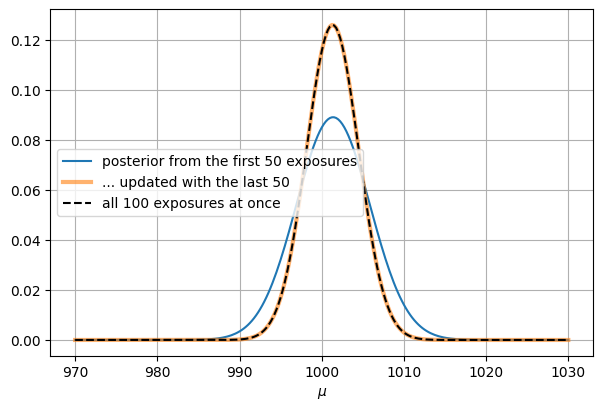

In [7]:
# split the counts in two halves and compare sequential with joint analysis (constant model, Poisson likelihood)
y1, y2 = y[:50], y[50:]
ll1 = np.array([np.sum(stats.poisson.logpmf(y1, mu)) for mu in mu_grid])
ll2 = np.array([np.sum(stats.poisson.logpmf(y2, mu)) for mu in mu_grid])
post1 = np.exp(ll1 - ll1.max()); post1 /= np.trapezoid(post1, mu_grid)               # posterior from first half
post12 = post1 * np.exp(ll2 - ll2.max()); post12 /= np.trapezoid(post12, mu_grid)     # updated with second half
joint = np.exp(ll1 + ll2 - (ll1 + ll2).max()); joint /= np.trapezoid(joint, mu_grid)  # all data at once

fig, ax = plt.subplots()
ax.plot(mu_grid, post1, label="posterior from the first 50 exposures")
ax.plot(mu_grid, post12, lw=3, alpha=0.6, label="... updated with the last 50")
ax.plot(mu_grid, joint, "k--", label="all 100 exposures at once")
ax.set_xlabel(r"$\mu$"); ax.legend();

(sec:reporting)=
## 4.6 Reporting the result: credible versus confidence intervals

*"Strictly speaking, the posterior distribution is our answer."* But papers need numbers. Common ways to summarize a posterior:

* the posterior **median** (or mean, or mode/MAP) as the point estimate, with the **equal-tailed 68.3% credible interval** as the uncertainty, written as $\mu = 1000 \pm 4$ or, for asymmetric intervals, $\epsilon = 18^{+5}_{-6}$;
* an **upper limit** when the posterior piles up against a boundary: "$\epsilon < 31$ (95%)";
* for joint constraints, a **contour plot** or a *corner plot* (Chapter 6) of the two-dimensional marginal posteriors;
* a set of **posterior samples**, so that any derived quantity can be computed with its full uncertainty (Chapter 6).

Finally, the difference in *meaning* between the two kinds of interval you now know:

| | frequentist **confidence interval** | Bayesian **credible interval** |
|---|---|---|
| the parameter is | a fixed, unknown number | a random variable with a probability distribution |
| the interval is | random: it depends on the data | fixed, given the data |
| the statement | "if we repeated the experiment many times, 68% of the intervals constructed this way would contain the true value" | "given these data (and the prior), the probability that the parameter lies in this interval is 68%" |
| computed from | the sampling distribution of the estimator (covariance, bootstrap) | the posterior (grid or MCMC) |

The Bayesian statement is the one everybody *wants* to make, and the one most people incorrectly attach to a confidence interval. In the literature the two terms are often mixed up; try not to.

## 4.7 Test yourself

````{admonition} Q1. Variability as a parameter (exam 2025)
:class: tip
We have 26 flux measurements $y_i$ with uncertainties $\sigma_{y,i}$ of the star Taylor.

1. Instead of hypothesis testing we can measure the variability by making it a free parameter of the statistical model. Write down the log-likelihood with additional variance $\epsilon^2$. Can you use this likelihood in a $\chi^2$-minimization algorithm like `curve_fit`?
2. Explain how the $p$-value of the null hypothesis and the new parameter $\epsilon^2$ are related.
3. Taylor was also observed once with HST in the same night; the HST point has ten times smaller variance $\sigma_y^2$ than our data. Explain how you include it in the analysis and how much it improves our sensitivity to variability.

```{admonition} Answer
:class: dropdown
1. $\ln\mathcal{L}(\mu,\epsilon) = -\frac12\sum_i\left[\ln 2\pi(\sigma_{y,i}^2+\epsilon^2) + \frac{(y_i-\mu)^2}{\sigma_{y,i}^2+\epsilon^2}\right]$. No: the $\ln(\sigma_{y,i}^2+\epsilon^2)$ term depends on the parameter and `curve_fit` only minimizes the sum of squared residuals with fixed weights. Use `minimize`, a grid or MCMC.
2. The null hypothesis "not variable" corresponds to $\epsilon=0$. A small $p$-value means the data are unlikely without extra scatter, so the posterior of $\epsilon$ will exclude zero (its lower credible bound is above zero); a large $p$-value means the posterior of $\epsilon$ is consistent with zero and only gives an upper limit.
3. Add the HST point to the dataset: it is one more term in the likelihood (or, equivalently, multiply the posterior by its likelihood, Eq. {eq}`eq:updating`). With ten times smaller variance it carries the weight of ten of our points, so it improves the constraint on the mean flux $\mu$ considerably, but a single point says little about the scatter *between* exposures: the sensitivity to $\epsilon$ improves only modestly (it is set by the number of exposures).
```
````

````{admonition} Q2. The posterior of a Poisson rate (exam 2023)
:class: tip
An experiment counts particles; the probability of $y$ counts given an expectation value $\lambda$ is $p(y\,|\,\lambda) = \lambda^y e^{-\lambda}/y!$. We observe 2 counts in 10 s and want the rate $\theta$ in counts per second, with a flat prior.

1. Write down Bayes' theorem and derive the posterior as a function of $\theta$.
2. Sketch it on the range $[0,1]$.
3. Explain how the 90% credible interval on $\theta$ can be computed.

```{admonition} Answer
:class: dropdown
1. $p(\theta\,|\,y=2) = p(y=2\,|\,\theta)\,p(\theta)/p(y=2)$. With $\lambda = 10\theta$: $p(y=2\,|\,\theta) = 50\theta^2 e^{-10\theta}$; the evidence is $p(y=2) = \int_0^\infty 50\theta^2e^{-10\theta}\,d\theta = 0.1$; with a constant prior the posterior is $p(\theta\,|\,y=2) = 500\,\theta^2 e^{-10\theta}$.
2. Zero at $\theta=0$, peak at $\theta = 0.2$, tail to the right, negligible by $\theta \approx 1$. Label the axes.
3. Find $(\theta_{\rm l}, \theta_{\rm u})$ such that $\int_{\theta_{\rm l}}^{\theta_{\rm u}} p(\theta\,|\,y)\,d\theta = 0.9$, e.g. the 5% and 95% quantiles of the posterior (equal-tailed) or the shortest such interval; numerically on a grid, or from MCMC samples by sorting them and taking the range that contains 90%.
```
````

## Sources and further reading

* Gelman et al. (2013), *Bayesian Data Analysis* (3rd ed.), [free PDF](https://sites.stat.columbia.edu/gelman/book/BDA3.pdf), Chapter 2 (single-parameter models, including the Poisson case) and Chapter 3 (marginalization, nuisance parameters).
* Hogg, Bovy & Lang (2010), [arXiv:1008.4686](https://arxiv.org/abs/1008.4686), Sections 4 and 8 (uncertainties, and intrinsic scatter as a model parameter).
* VanderPlas (2014), *Frequentism and Bayesianism: a practical introduction* ([blog post](http://jakevdp.github.io/blog/2014/03/11/frequentism-and-bayesianism-a-practical-intro/)), for the photon-flux example with intrinsic scatter.
* Kelly (2007), *Some aspects of measurement error in linear regression of astronomical data*, ApJ 665, 1489, [arXiv:0705.2774](https://arxiv.org/abs/0705.2774), for intrinsic scatter in relations between astronomical quantities.